<a href="https://colab.research.google.com/github/Aflian/COLLAB-ANDRA/blob/main/lstm_pso_gold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediksi Harga Emas Menggunakan LSTM + PSO
Notebook ini mencakup:
- Data Cleaning
- Preprocessing
- LSTM Model
- Optimasi PSO
- Evaluasi RMSE, MAE, MAPE
- Visualisasi hasil prediksi
- Grafik error dan distribusi error

In [1]:
!pip install pandas numpy scikit-learn tensorflow matplotlib pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

import pyswarms as ps

## Upload Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Gold Futures Historical Data (3).csv to Gold Futures Historical Data (3).csv


## Load Dataset

In [4]:
df = pd.read_csv("Gold Futures Historical Data (3).csv")
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,03/16/2026,"5,009.39","5,003.10","5,044.36","4,973.69",0.77K,0.17%
1,03/15/2026,"5,001.04","5,003.10","5,034.30","4,971.30",NaN,-1.20%
2,03/13/2026,"5,061.70","5,084.00","5,132.40","5,014.10",160.33K,-1.25%
3,03/12/2026,"5,125.80","5,185.40","5,197.80","5,058.20",153.53K,-1.03%
4,03/11/2026,"5,179.10","5,194.00","5,230.90","5,155.90",140.34K,-1.20%


## Data Cleaning

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

for col in ['Price','Open','High','Low']:
    df[col] = df[col].astype(str).str.replace(',','')
    df[col] = pd.to_numeric(df[col], errors='coerce')

def convert_volume(x):
    x = str(x)
    if 'K' in x:
        return float(x.replace('K','')) * 1000
    elif 'M' in x:
        return float(x.replace('M','')) * 1000000
    else:
        return pd.to_numeric(x, errors='coerce')

df['Vol.'] = df['Vol.'].apply(convert_volume)

df['Change %'] = df['Change %'].astype(str).str.replace('%','')
df['Change %'] = pd.to_numeric(df['Change %'], errors='coerce')

df = df.sort_values('Date')
df = df.dropna()
df = df.set_index('Date')

df.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2020-01-02,1552.4,1531.7,1556.6,1530.4,436740.0,1.92
2020-01-03,1552.4,1531.7,1556.6,1530.4,436740.0,0.00
2020-01-06,1568.8,1562.7,1590.9,1562.3,558970.0,1.06
2020-01-07,1574.3,1567.4,1579.2,1557.0,435870.0,0.35
2020-01-08,1560.2,1578.8,1613.3,1553.4,813410.0,-0.90


## Feature Selection

In [6]:
features = ['Price','Open','High','Low','Vol.','Change %']
data = df[features]

## Normalisasi Data

In [7]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_data = np.nan_to_num(scaled_data)

## Membuat Dataset Time Series

In [8]:
sequence = 10
X = []
y = []

for i in range(sequence, len(scaled_data)):
    X.append(scaled_data[i-sequence:i])
    y.append(scaled_data[i,0])

X = np.array(X)
y = np.array(y)

## Split Dataset

In [9]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

## Model LSTM

In [10]:
def build_model(neurons):

    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
    model.add(LSTM(int(neurons), return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(int(neurons/2)))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')

    return model

## Fungsi Evaluasi Model

In [11]:
def evaluate_model(model):

    pred = model.predict(X_test)
    pred = np.nan_to_num(pred)

    pred_price = scaler.inverse_transform(
        np.concatenate((pred,np.zeros((pred.shape[0],5))),axis=1)
    )[:,0]

    real_price = scaler.inverse_transform(
        np.concatenate((y_test.reshape(-1,1),np.zeros((y_test.shape[0],5))),axis=1)
    )[:,0]

    rmse = np.sqrt(mean_squared_error(real_price,pred_price))

    return rmse

## Optimasi PSO

In [12]:
def objective_function(x):

    n_particles = x.shape[0]
    scores = []

    for i in range(n_particles):

        neurons = int(x[i][0])
        model = build_model(neurons)

        model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

        score = evaluate_model(model)
        scores.append(score)

    return np.array(scores)

## Jalankan PSO

In [13]:
options = {'c1':0.5,'c2':0.3,'w':0.9}

optimizer = ps.single.GlobalBestPSO(
    n_particles=5,
    dimensions=1,
    options=options,
    bounds=(np.array([16]),np.array([128]))
)

best_cost, best_pos = optimizer.optimize(objective_function, iters=10)

best_neuron = int(best_pos[0])

print("Neuron terbaik:", best_neuron)

2026-03-16 23:51:05,338 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|          |0/10

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


pyswarms.single.global_best:  10%|█         |1/10, best_cost=105

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


pyswarms.single.global_best:  20%|██        |2/10, best_cost=105

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


pyswarms.single.global_best:  90%|█████████ |9/10, best_cost=105

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


pyswarms.single.global_best: 100%|██████████|10/10, best_cost=101
2026-03-16 23:56:52,622 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 101.08045242656291, best pos: [112.56680353]


Neuron terbaik: 112


## Training Model Terbaik

In [14]:
model = build_model(best_neuron)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0021 - val_loss: 9.7703e-04
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.8343e-04 - val_loss: 0.0018
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.6005e-04 - val_loss: 0.0023
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 1.6048e-04 - val_loss: 0.0012
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.5178e-04 - val_loss: 0.0019
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.6811e-04 - val_loss: 0.0017
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.3261e-04 - val_loss: 0.0012
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.3522e-04 - val_loss: 0.0011
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.2182e-04 - val_loss: 0.0024
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.3903e-04 - val_loss: 7.0656e-04
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.2000e-04 - val_loss: 8.0555e-04
Epoch 12/30

## Prediksi

In [15]:
pred = model.predict(X_test)

pred_price = scaler.inverse_transform(
    np.concatenate((pred,np.zeros((pred.shape[0],5))),axis=1)
)[:,0]

real_price = scaler.inverse_transform(
    np.concatenate((y_test.reshape(-1,1),np.zeros((y_test.shape[0],5))),axis=1)
)[:,0]

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


## Evaluasi Model

In [16]:
rmse = np.sqrt(mean_squared_error(real_price,pred_price))
mae = mean_absolute_error(real_price,pred_price)
mape = np.mean(np.abs((real_price-pred_price)/real_price))*100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

RMSE: 127.43365446103002
MAE: 98.53966786073666
MAPE: 2.5176447984888792


## Visualisasi Harga Asli vs Prediksi

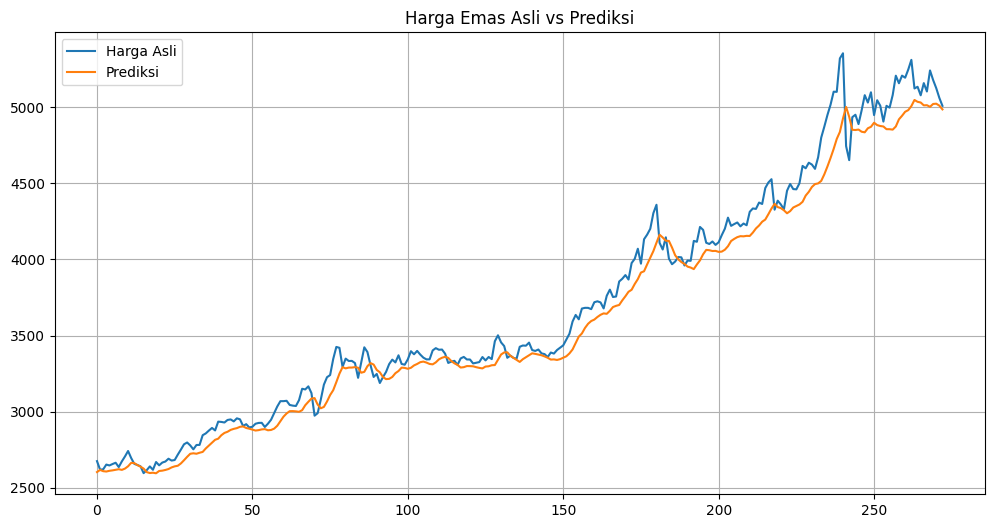

In [17]:
plt.figure(figsize=(12,6))
plt.plot(real_price,label="Harga Asli")
plt.plot(pred_price,label="Prediksi")
plt.title("Harga Emas Asli vs Prediksi")
plt.legend()
plt.grid()
plt.show()

## Visualisasi Error

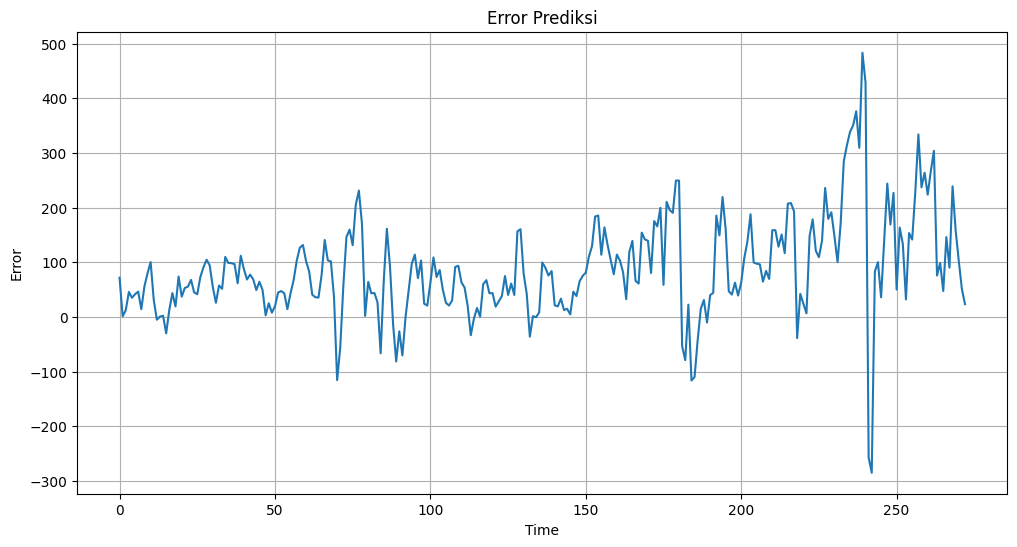

In [18]:
error = real_price - pred_price

plt.figure(figsize=(12,6))
plt.plot(error)
plt.title("Error Prediksi")
plt.xlabel("Time")
plt.ylabel("Error")
plt.grid()
plt.show()

## Visualisasi Distribusi Error

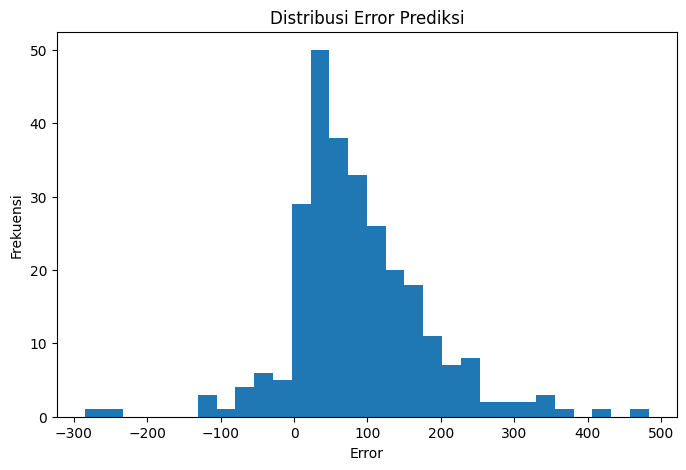

In [19]:
plt.figure(figsize=(8,5))
plt.hist(error,bins=30)
plt.title("Distribusi Error Prediksi")
plt.xlabel("Error")
plt.ylabel("Frekuensi")
plt.show()

## Visualisasi Evaluasi Model

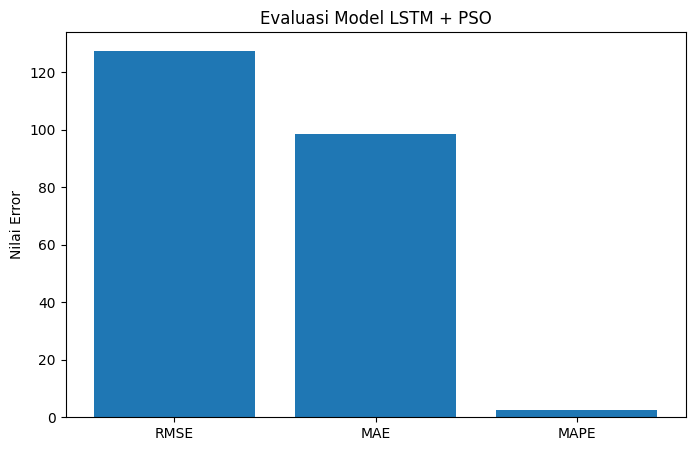

In [20]:
metrics = ["RMSE","MAE","MAPE"]
values = [rmse,mae,mape]

plt.figure(figsize=(8,5))
plt.bar(metrics,values)
plt.title("Evaluasi Model LSTM + PSO")
plt.ylabel("Nilai Error")
plt.show()